<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 0: Why Superconducting Electronics?</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Why Superconducting Electronics? - SCE Futures</p>
</div>

## Contents

1. [The Problem: Computing's Energy Crisis](#1-energy-crisis)
2. [The Opportunity: Superconducting Electronics](#2-opportunity)
3. [Why AQFP?](#3-why-aqfp)
4. [Where SCE Fits](#4-where-fits)
5. [Where SCE Does NOT Fit](#5-where-not)
6. [Open Problems](#6-open-problems)
7. [The Path Forward](#7-path-forward)
8. [Key Takeaways](#8-takeaways)

In [1]:
# Setup
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
import numpy as np

COLORS = {
    'primary': '#2196F3',
    'secondary': '#FF9800',
    'success': '#4CAF50',
    'danger': '#f44336',
    'dark': '#1a1a2e',
    'light': '#f5f5f5',
    'purple': '#9C27B0',
    'cyan': '#00BCD4',
    'cmos': '#f44336',
    'sce': '#4CAF50',
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


---
<a id="1-energy-crisis"></a>
# 1. The Problem: Computing's Energy Crisis
---

## AI is Eating the Grid

The explosive growth of AI - particularly large language models - has created an unprecedented demand for compute. This demand is fundamentally **energy-limited**.

| Metric | 2020 | 2024 | 2028 (projected) |
|--------|------|------|------------------|
| Global datacenter power | 200 TWh | 400 TWh | 1,000+ TWh |
| AI training power (single run) | 1 MW | 50 MW | 500+ MW |
| LLM inference power (global) | ~1 GW | ~20 GW | ~100+ GW |

**The problem is not compute density - it's power.**

## Moore's Law is Over (For Power)

CMOS scaling has hit fundamental limits:

- **Dennard scaling ended ~2006**: Voltage no longer scales with transistor size
- **Leakage dominates**: Sub-threshold current grows exponentially at small nodes
- **Wire resistance increases**: Interconnect RC delay now dominates gate delay

The result: **energy per operation has plateaued** at ~1 pJ/op for CMOS logic.

## The AI Scaling Dilemma

AI capabilities scale with compute. But:

- Training GPT-4 class models: ~$100M in electricity
- Running inference at scale: $1B+/year in power costs
- Next-generation models: 10-100× more compute needed

**We cannot build the AI future on CMOS alone.**

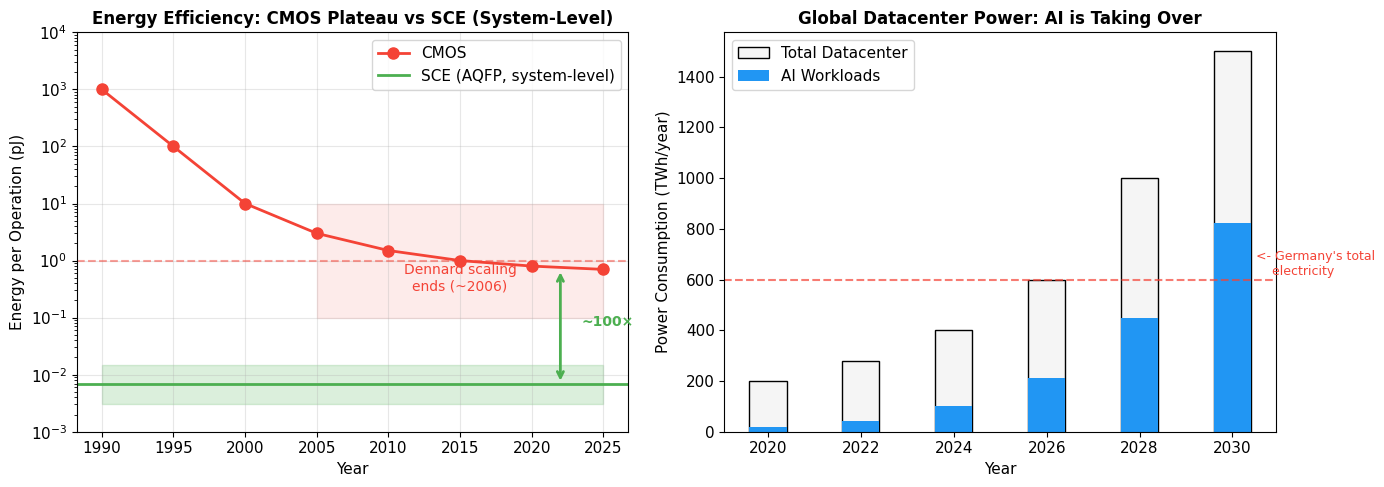


~100× system-level advantage (includes cooling overhead, memory/IO)
This is the relevant comparison for real AI workloads.


In [2]:
# Visualize: Energy efficiency trends (system-level comparison)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CMOS energy plateau vs SCE target
ax = axes[0]
years = np.array([1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025])
cmos_energy = np.array([1000, 100, 10, 3, 1.5, 1.0, 0.8, 0.7])  # pJ/op

ax.semilogy(years, cmos_energy, 'o-', color=COLORS['cmos'], linewidth=2, markersize=8, label='CMOS')
ax.axhline(y=1, color=COLORS['cmos'], linestyle='--', alpha=0.5)
ax.fill_between([2005, 2025], [0.1, 0.1], [10, 10], alpha=0.1, color=COLORS['cmos'])
ax.text(2015, 0.3, 'Dennard scaling\nends (~2006)', ha='center', fontsize=10, color=COLORS['cmos'])

# SCE system-level: ~100× real-workload advantage vs CMOS at 0.7 pJ → show at ~0.007 pJ
ax.axhline(y=0.007, color=COLORS['sce'], linestyle='-', linewidth=2, label='SCE (AQFP, system-level)')
ax.fill_between([1990, 2025], [0.003, 0.003], [0.015, 0.015], alpha=0.2, color=COLORS['sce'])

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Energy per Operation (pJ)', fontsize=11)
ax.set_title('Energy Efficiency: CMOS Plateau vs SCE (System-Level)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(1e-3, 1e4)
ax.grid(True, alpha=0.3)

# Annotation
ax.annotate('', xy=(2022, 0.007), xytext=(2022, 0.7),
            arrowprops=dict(arrowstyle='<->', color=COLORS['success'], lw=2))
ax.text(2023.5, 0.07, '~100×', fontsize=10, color=COLORS['success'], fontweight='bold')

# Datacenter power projection
ax = axes[1]
years = [2020, 2022, 2024, 2026, 2028, 2030]
dc_power = [200, 280, 400, 600, 1000, 1500]  # TWh
ai_fraction = [0.1, 0.15, 0.25, 0.35, 0.45, 0.55]

ax.bar(years, dc_power, color=COLORS['light'], edgecolor='black', label='Total Datacenter')
ax.bar(years, [p*f for p, f in zip(dc_power, ai_fraction)], color=COLORS['primary'], label='AI Workloads')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Power Consumption (TWh/year)', fontsize=11)
ax.set_title('Global Datacenter Power: AI is Taking Over', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

# World reference line
ax.axhline(y=600, color=COLORS['danger'], linestyle='--', alpha=0.7)
ax.text(2030.5, 620, '<- Germany\'s total\n    electricity', fontsize=9, color=COLORS['danger'])

plt.tight_layout()
plt.show()

print("\n~100× system-level advantage (includes cooling overhead, memory/IO)")
print("This is the relevant comparison for real AI workloads.")

---
<a id="2-opportunity"></a>
# 2. The Opportunity: Superconducting Electronics
---

## What is Superconducting Electronics?

**Superconductors** are materials that conduct electricity with **zero resistance** below a critical temperature (typically 4-10 Kelvin, or -269°C to -263°C).

**Superconducting Electronics (SCE)** uses these materials to build digital logic circuits that eliminate the two dominant sources of energy loss in CMOS.

## The Physics Advantage

CMOS dissipates energy through two mechanisms:

1. **Ohmic losses (I²R)**: Current flowing through resistive interconnects and transistor channels generates heat.
2. **Capacitive losses (½CV²)**: Charging and discharging gate/wire capacitances at high voltage swings (0.7-1V) dissipates energy.

SCE eliminates both:

- **Zero resistance** → No ohmic losses. Superconducting wires carry current with no I²R dissipation.
- **Near-zero voltage** → No capacitive losses. SCE uses current-mode signaling with µV-scale voltages, so ½CV² ≈ 0.

| Property | CMOS | SCE |
|----------|------|-----|
| Switching mechanism | Charge movement (voltage) | Magnetic flux quanta (current) |
| Signal voltage | ~0.7-1V | ~µV |
| Interconnect resistance | Finite (I²R heat) | Zero |
| Minimum switching energy | ~100,000 kT | ~1 kT (approaching thermodynamic limit) |
| Operating frequency | 1-5 GHz practical | 5-10 GHz (AQFP), >50 GHz (*SFQ) |

**The key insight**: Zero resistance and current-mode operation eliminate both I²R and CV² losses.

## The Numbers

> **Convention**: All comparisons below are **system-level**, including ~1000× cooling overhead for cryogenic operation. This provides apples-to-apples comparisons against room-temperature CMOS.

| Metric | CMOS (7nm) | SCE (AQFP) | Advantage |
|--------|------------|------------|------------|
| Energy/switch | ~1 pJ | ~10 fJ | **~100×** |
| Clock frequency | 3 GHz | 5-10 GHz | **2-3×** |
| Interconnect loss | High (RC) | Zero (superconducting) | **~200×** |

**Note**: Real workload efficiency depends on arithmetic intensity. High arithmetic intensity workloads (like LLM inference) achieve **~100× system-level advantage**. Efficiency drops when data must frequently cross thermal boundaries (4K ↔ 300K).

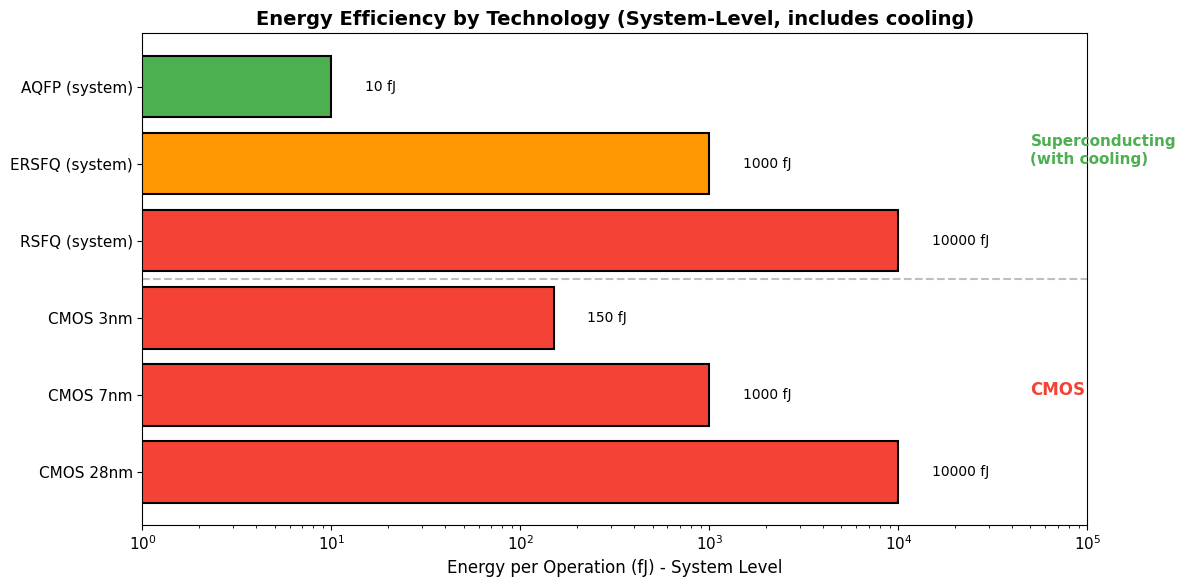

System-level comparison (includes ~1000× cooling overhead for SCE):
- RSFQ: comparable to CMOS 28nm after cooling
- ERSFQ: comparable to CMOS 7nm after cooling
- AQFP: ~100× better than CMOS 7nm (~10 fJ system vs ~1 pJ)


In [3]:
# Visualize: Energy comparison (system-level, includes cooling overhead for SCE)
fig, ax = plt.subplots(figsize=(12, 6))

# System-level values: SCE chip energy × 1000 cooling overhead
# RSFQ: 10 aJ chip × 1000 = 10,000 fJ system (comparable to CMOS 28nm)
# ERSFQ: 1 aJ chip × 1000 = 1000 fJ system (comparable to CMOS 7nm)
# AQFP: ~1.4 zJ chip × 1000 = ~1.4 fJ; with circuit overhead ~10 fJ system (~100× better than CMOS)
technologies = [
    ('CMOS 28nm', 10000, COLORS['cmos']),
    ('CMOS 7nm', 1000, COLORS['cmos']),
    ('CMOS 3nm', 150, COLORS['cmos']),
    ('RSFQ (system)', 10000, COLORS['danger']),        # 10 aJ × 1000 = 10 fJ = 10,000 fJ system (comparable to CMOS 28nm)
    ('ERSFQ (system)', 1000, COLORS['secondary']),     # 1 aJ × 1000 = 1 fJ = 1000 fJ system (comparable to CMOS 7nm)
    ('AQFP (system)', 10, COLORS['sce']),        # ~1.4 zJ × 1000 = ~1.4 fJ; ~10 fJ with overhead (100× better)
]

names = [t[0] for t in technologies]
energies = [t[1] for t in technologies]
colors = [t[2] for t in technologies]

bars = ax.barh(names, energies, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xscale('log')
ax.set_xlabel('Energy per Operation (fJ) - System Level', fontsize=12)
ax.set_title('Energy Efficiency by Technology (System-Level, includes cooling)', fontsize=14, fontweight='bold')

# Add value labels
for bar, energy in zip(bars, energies):
    ax.text(energy * 1.5, bar.get_y() + bar.get_height()/2, 
            f'{energy} fJ', va='center', fontsize=10)

# Grouping annotations - CMOS at bottom (y=0,1,2), SCE at top (y=3,4,5)
ax.axhline(y=2.5, color='gray', linestyle='--', alpha=0.5)
ax.text(50000, 1, 'CMOS', fontsize=12, fontweight='bold', color=COLORS['cmos'])
ax.text(50000, 4, 'Superconducting\n(with cooling)', fontsize=11, fontweight='bold', color=COLORS['sce'])

ax.set_xlim(1, 100000)
plt.tight_layout()
plt.show()

print("System-level comparison (includes ~1000× cooling overhead for SCE):")
print("- RSFQ: comparable to CMOS 28nm after cooling")
print("- ERSFQ: comparable to CMOS 7nm after cooling")
print("- AQFP: ~100× better than CMOS 7nm (~10 fJ system vs ~1 pJ)")

## System Architecture

An SCE system integrates superconducting chips within a cryogenic environment. Understanding this architecture is essential for grasping the thermal budget constraints:

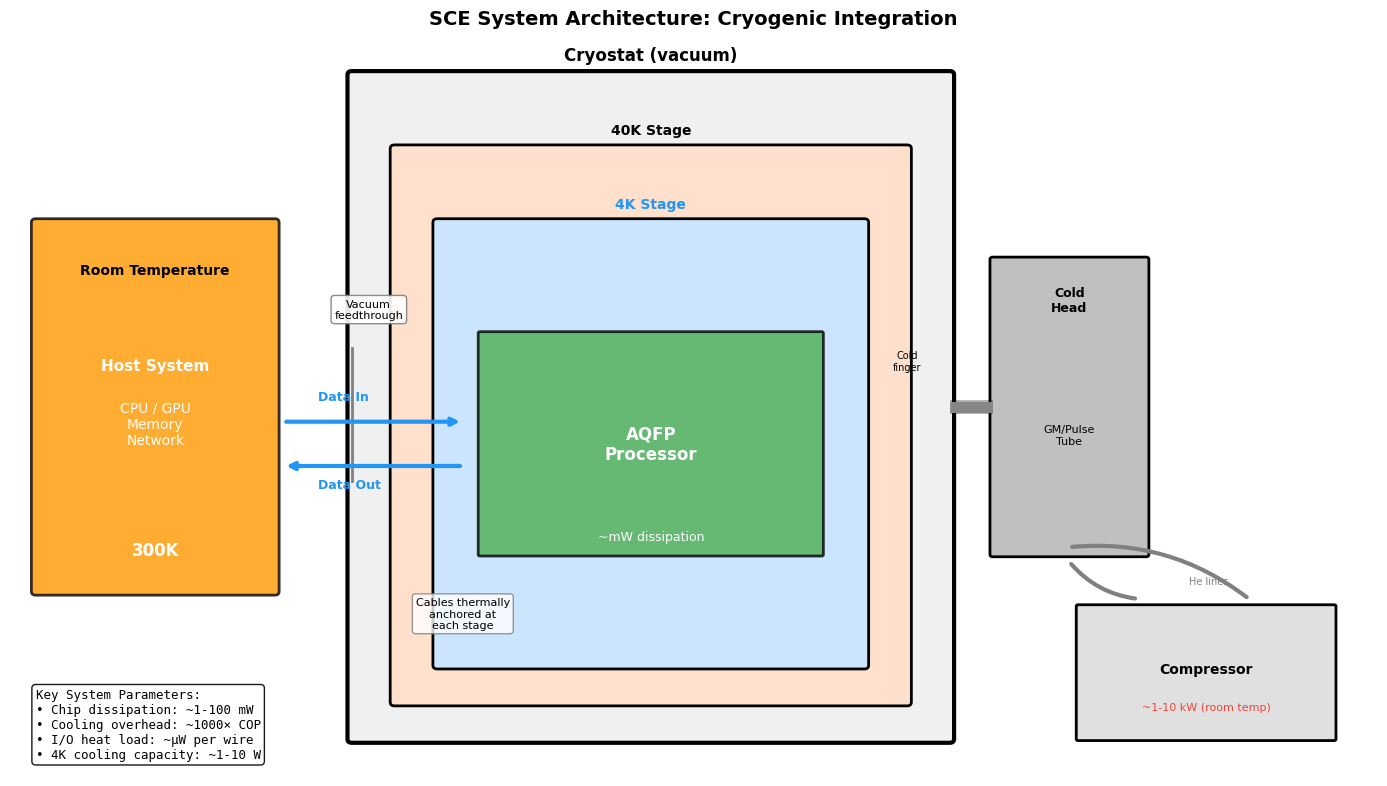

The thermal boundary is where the I/O challenge lives:
- Every data wire conducts heat into the 4K stage
- Cables are thermally anchored at 40K and 4K to intercept heat
- High arithmetic intensity minimizes data crossing the boundary


In [4]:
# Visualize: SCE System Architecture
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')

# Color scheme for temperature zones
colors_temp = {
    '40K': '#ffe0cc',   # orange
    '4K': '#cce5ff',    # cold blue
}

# === CRYOSTAT (center) ===
# Cryostat vacuum vessel (outer boundary) - narrower to leave room for external components
cryostat = FancyBboxPatch((4, 0.5), 7, 9, boxstyle="round,pad=0.05",
                           facecolor='#f0f0f0', edgecolor='black', linewidth=3)
ax.add_patch(cryostat)
ax.text(7.5, 9.7, 'Cryostat (vacuum)', ha='center', fontsize=12, fontweight='bold')

# 40K - Intermediate stage (radiation shield)
stage_40k = FancyBboxPatch((4.5, 1), 6, 7.5, boxstyle="round,pad=0.05",
                            facecolor=colors_temp['40K'], edgecolor='black', linewidth=2)
ax.add_patch(stage_40k)
ax.text(7.5, 8.7, '40K Stage', ha='center', fontsize=10, fontweight='bold')

# 4K - Cold stage (innermost)
stage_4k = FancyBboxPatch((5, 1.5), 5, 6, boxstyle="round,pad=0.05",
                           facecolor=colors_temp['4K'], edgecolor='black', linewidth=2)
ax.add_patch(stage_4k)
ax.text(7.5, 7.7, '4K Stage', ha='center', fontsize=10, fontweight='bold', color=COLORS['primary'])

# SCE Chip at 4K
chip = FancyBboxPatch((5.5, 3), 4, 3, boxstyle="round,pad=0.02",
                       facecolor=COLORS['sce'], edgecolor='black', linewidth=2, alpha=0.8)
ax.add_patch(chip)
ax.text(7.5, 4.5, 'AQFP\nProcessor', ha='center', va='center', fontsize=12, 
        fontweight='bold', color='white')
ax.text(7.5, 3.2, '~mW dissipation', ha='center', fontsize=9, color='white')

# === COLD HEAD (outside cryostat, connected via flange) ===
cryo_head = FancyBboxPatch((11.5, 3), 1.8, 4, boxstyle="round,pad=0.03",
                            facecolor='#c0c0c0', edgecolor='black', linewidth=2)
ax.add_patch(cryo_head)
ax.text(12.4, 6.3, 'Cold\nHead', ha='center', fontsize=9, fontweight='bold')
ax.text(12.4, 4.5, 'GM/Pulse\nTube', ha='center', fontsize=8)

# Cold finger penetrating into cryostat
ax.plot([11, 11.5], [5, 5], color='#c0c0c0', linewidth=8, solid_capstyle='butt')
ax.plot([11, 11.5], [5, 5], color='black', linewidth=10, solid_capstyle='butt', alpha=0.3)
ax.text(10.5, 5.5, 'Cold\nfinger', fontsize=7, ha='center')

# === COMPRESSOR (external, bottom right) ===
compressor = FancyBboxPatch((12.5, 0.5), 3, 1.8, boxstyle="round,pad=0.02",
                             facecolor='#e0e0e0', edgecolor='black', linewidth=2)
ax.add_patch(compressor)
ax.text(14, 1.4, 'Compressor', ha='center', fontsize=10, fontweight='bold')
ax.text(14, 0.9, '~1-10 kW (room temp)', ha='center', fontsize=8, color=COLORS['danger'])

# Helium lines connecting compressor to cold head
ax.annotate('', xy=(12.4, 2.9), xytext=(13.2, 2.4),
            arrowprops=dict(arrowstyle='-', color='gray', lw=3, 
                          connectionstyle='arc3,rad=-0.2'))
ax.annotate('', xy=(12.4, 3.1), xytext=(14.5, 2.4),
            arrowprops=dict(arrowstyle='-', color='gray', lw=3,
                          connectionstyle='arc3,rad=0.2'))
ax.text(13.8, 2.6, 'He lines', fontsize=7, color='gray')

# === HOST SYSTEM (left side, completely outside cryostat) ===
host = FancyBboxPatch((0.3, 2.5), 2.8, 5, boxstyle="round,pad=0.05",
                       facecolor=COLORS['secondary'], edgecolor='black', linewidth=2, alpha=0.8)
ax.add_patch(host)
ax.text(1.7, 6.8, 'Room Temperature', ha='center', fontsize=10, fontweight='bold')
ax.text(1.7, 5.5, 'Host System', ha='center', fontsize=11, fontweight='bold', color='white')
ax.text(1.7, 4.5, 'CPU / GPU\nMemory\nNetwork', ha='center', fontsize=10, color='white')
ax.text(1.7, 3.0, '300K', ha='center', fontsize=12, fontweight='bold', color='white')

# === I/O CABLES (crossing into cryostat) ===
ax.annotate('', xy=(5.3, 4.8), xytext=(3.2, 4.8),
            arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=3))
ax.annotate('', xy=(3.2, 4.2), xytext=(5.3, 4.2),
            arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=3))

ax.text(3.6, 5.1, 'Data In', fontsize=9, color=COLORS['primary'], fontweight='bold')
ax.text(3.6, 3.9, 'Data Out', fontsize=9, color=COLORS['primary'], fontweight='bold')

# Feedthrough annotation
ax.text(4.2, 6.2, 'Vacuum\nfeedthrough', fontsize=8, ha='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
ax.plot([4.0, 4.0], [4.0, 5.8], color='gray', linewidth=2, linestyle='-')

# Thermal anchoring note
ax.text(5.3, 2.0, 'Cables thermally\nanchored at\neach stage', fontsize=8, ha='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8))

# === KEY METRICS BOX ===
metrics_text = """Key System Parameters:
• Chip dissipation: ~1-100 mW
• Cooling overhead: ~1000× COP
• I/O heat load: ~µW per wire
• 4K cooling capacity: ~1-10 W"""

ax.text(0.3, 0.2, metrics_text, fontsize=9, fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.9),
        verticalalignment='bottom')

# Title
ax.set_title('SCE System Architecture: Cryogenic Integration', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

print("The thermal boundary is where the I/O challenge lives:")
print("- Every data wire conducts heat into the 4K stage")
print("- Cables are thermally anchored at 40K and 4K to intercept heat")
print("- High arithmetic intensity minimizes data crossing the boundary")

---
<a id="3-why-aqfp"></a>
# 3. Why AQFP?
---

There are several superconducting logic families. **AQFP (Adiabatic Quantum-Flux-Parametron)** is the most promising for AI acceleration.

## SCE Logic Family Comparison

| Family | Energy/op | Speed | Maturity | Best For |
|--------|-----------|-------|----------|----------|
| **RSFQ** | ~10 aJ | >50 GHz | High | High-speed digital |
| **ERSFQ** | ~1 aJ | >50 GHz | Medium | Lower power RSFQ |
| **AQFP** | ~1 zJ (single gate) | 5-10 GHz | Medium | Ultra-low power |
| **RQL** | ~0.1 aJ | 10 GHz | Low | Reciprocal logic |

**Note on AQFP energy:** The ~1 zJ figure is single-gate switching energy. Real chip-level energy is higher due to clock distribution and I/O, but AQFP still maintains a ~1000× advantage over RSFQ at the gate level.

## Why AQFP Wins for AI

### 1. Energy Efficiency
AQFP operates near the **thermodynamic limit** of computation - the theoretical minimum energy to perform a logical operation. No other technology comes close.

### 2. Adiabatic Operation
- Energy is **recycled** rather than dissipated
- Switching happens gradually (adiabatically), not abruptly
- Result: ~10,000× less heat than RSFQ, ~1000× less than ERSFQ

### 3. Clocking Simplicity
- Uses AC excitation (like a sine wave), not pulse-based clocking
- Easier to distribute than SFQ pulses
- More tolerant to timing variations

### 4. Deterministic Dataflow
- Data flows through pipeline stages in lock-step
- Each AQFP gate is inherently a flip-flop, providing intrinsic memory at every stage (equivalent to ~28 CMOS transistors)
- **Well-suited for systolic array / matrix multiplication workloads** (same workloads GPUs target)

## System-Level Efficiency (with ~1000× Cooling Overhead)

| Family | Gate Energy | With Cooling | vs CMOS 7nm |
|--------|-------------|--------------|-------------|
| **RSFQ** | ~10 aJ | ~10 fJ | ~0.1× (10× worse) |
| **ERSFQ** | ~1 aJ | ~1 fJ | ~1× (breaks even) |
| **AQFP** | ~1 zJ | ~1 aJ | **~100× (realistic system)** |

**Note:** AQFP's ~1000× gate-level advantage becomes ~100× at system level after accounting for clock distribution, I/O, and realistic chip overhead. Still a compelling advantage over CMOS — and the only SCE family that delivers significant system-level gains after cooling.

**Arithmetic intensity matters**: The realized efficiency scales with data reuse. High arithmetic intensity workloads (like large matrix multiplications in LLM inference) achieve the full **~100× system-level advantage**. Lower arithmetic intensity workloads see reduced gains when data must cross thermal boundaries (particularly 4K → 300K).

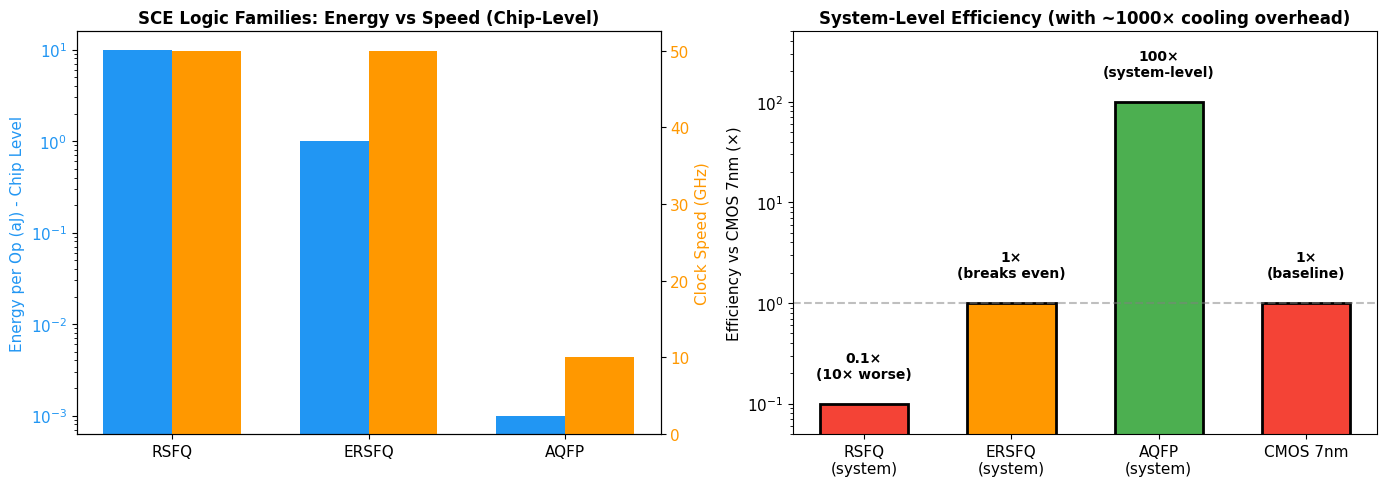

AQFP: ~100× system-level advantage vs CMOS (includes cooling overhead)
This is the realistic comparison for AI workloads.


In [5]:
# Visualize: AQFP advantage breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logic family comparison (chip-level, for comparing SCE families)
ax = axes[0]
families = ['RSFQ', 'ERSFQ', 'AQFP']
energy = [10, 1, 0.001]  # aJ (chip-level): RSFQ 10 aJ, ERSFQ 1 aJ, AQFP ~1 zJ = 0.001 aJ
speed = [50, 50, 10]  # GHz

x = np.arange(len(families))
width = 0.35

bars1 = ax.bar(x - width/2, energy, width, label='Energy (aJ, chip)', color=COLORS['primary'])
ax.set_ylabel('Energy per Op (aJ) - Chip Level', color=COLORS['primary'])
ax.tick_params(axis='y', labelcolor=COLORS['primary'])
ax.set_yscale('log')

ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, speed, width, label='Speed (GHz)', color=COLORS['secondary'])
ax2.set_ylabel('Clock Speed (GHz)', color=COLORS['secondary'])
ax2.tick_params(axis='y', labelcolor=COLORS['secondary'])

ax.set_xticks(x)
ax.set_xticklabels(families)
ax.set_title('SCE Logic Families: Energy vs Speed (Chip-Level)', fontsize=12, fontweight='bold')

# System-level efficiency comparison
ax = axes[1]

families_sys = ['RSFQ\n(system)', 'ERSFQ\n(system)', 'AQFP\n(system)', 'CMOS 7nm']
efficiency_vs_cmos = [0.1, 1, 100, 1]  # × efficiency vs CMOS (higher = better) - AQFP ~100× system-level
colors_sys = [COLORS['danger'], COLORS['secondary'], COLORS['sce'], COLORS['cmos']]

bars = ax.bar(families_sys, efficiency_vs_cmos, color=colors_sys, 
              edgecolor='black', linewidth=2, width=0.6)
ax.set_ylabel('Efficiency vs CMOS 7nm (×)', fontsize=11)
ax.set_title('System-Level Efficiency (with ~1000× cooling overhead)', fontsize=12, fontweight='bold')
ax.set_yscale('log')

# Add value labels
labels = ['0.1×\n(10× worse)', '1×\n(breaks even)', '100×\n(system-level)', '1×\n(baseline)']
for bar, label in zip(bars, labels):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height * 1.8,
            label, ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0.05, 500)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("AQFP: ~100× system-level advantage vs CMOS (includes cooling overhead)")
print("This is the realistic comparison for AI workloads.")

---
<a id="4-where-fits"></a>
# 4. Where SCE Fits
---

SCE excels in specific application domains:

## Ideal Applications

### 1. AI Inference at Scale
- **LLM inference**: Matrix-dominated compute, predictable memory access (batch for throughput)
- **Vision models (CNNs, ViTs)**: High arithmetic intensity convolutions
- **Diffusion models**: Predominantly compute-bound (attention + conv layers)

### 2. High-Performance Computing
- **Weather/climate modeling**: Regular compute patterns
- **Molecular dynamics**: Dense linear algebra
- **Signal processing**: FFTs, convolutions

### 3. Already-Cryogenic Applications (No Cooling Penalty!)
These applications **already require cryogenic temperatures**, so SCE doesn't pay the ~1000× cooling overhead. The comparison is SCE vs cryo-CMOS at 4K:

- **Quantum computer control**: Qubits already at mK; SCE control at 4K is ideal
- **Radio astronomy**: SIS mixers and SQUID amplifiers already at cryo
- **MEG/biomagnetism**: SQUID sensors already at 4K

For these applications, SCE delivers the **full ~100,000× chip-level advantage** (100× system advantage × 1000× cooling overhead that's now free).

## Common Characteristics of Good SCE Workloads

| Characteristic | Why It Matters |
|----------------|----------------|
| High arithmetic intensity | Amortizes cooling overhead |
| Predictable memory access | Enables register-heavy architecture |
| Parallelizable | Maps to systolic arrays |
| Throughput > latency | Tolerates pipeline depth |
| Always-on operation | Avoids cryo cycling costs |
| Already cryogenic | No cooling penalty - full ~100,000× advantage |

**Note**: These are the same workload characteristics that GPUs/TPUs target. SCE's advantage is efficiency in the compute-bound regime, not different workload requirements.

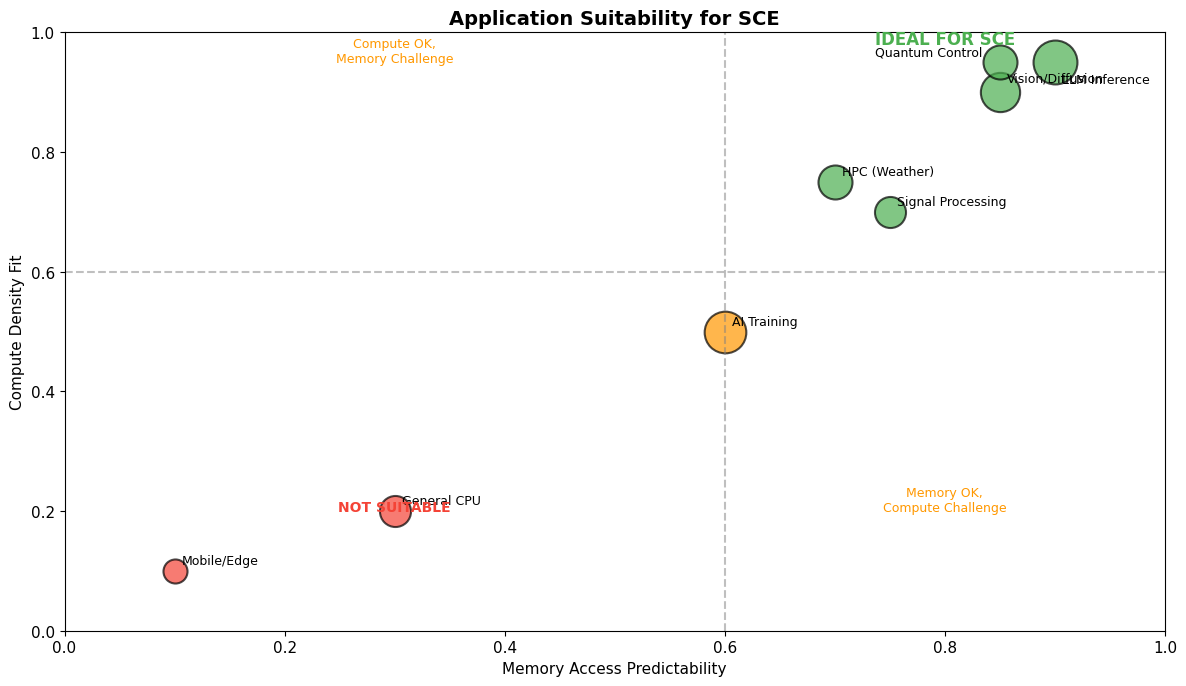

Quantum Control is ideal: already cryogenic, so SCE gets full ~100,000× advantage.


In [6]:
# Visualize: Application fit matrix
fig, ax = plt.subplots(figsize=(12, 7))

# (name, compute_fit, memory_fit, size, label_offset_x, label_offset_y)
applications = [
    ('LLM Inference', 0.95, 0.9, 100, 5, -15),
    ('Vision/Diffusion', 0.9, 0.85, 80, 5, 8),
    ('Quantum Control', 0.95, 0.85, 60, -90, 5),
    ('HPC (Weather)', 0.75, 0.7, 60, 5, 5),
    ('Signal Processing', 0.7, 0.75, 50, 5, 5),
    ('AI Training', 0.5, 0.6, 90, 5, 5),
    ('General CPU', 0.2, 0.3, 50, 5, 5),
    ('Mobile/Edge', 0.1, 0.1, 30, 5, 5),
]

for name, compute_fit, memory_fit, size, off_x, off_y in applications:
    color = COLORS['sce'] if compute_fit > 0.6 and memory_fit > 0.6 else COLORS['secondary'] if compute_fit > 0.4 or memory_fit > 0.4 else COLORS['cmos']
    ax.scatter(memory_fit, compute_fit, s=size*10, c=color, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax.annotate(name, (memory_fit, compute_fit), xytext=(off_x, off_y), textcoords='offset points', fontsize=9)

# Quadrant lines
ax.axhline(y=0.6, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0.6, color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(0.8, 0.98, 'IDEAL FOR SCE', fontsize=12, fontweight='bold', color=COLORS['sce'], ha='center')
ax.text(0.3, 0.95, 'Compute OK,\nMemory Challenge', fontsize=9, ha='center', color=COLORS['secondary'])
ax.text(0.8, 0.2, 'Memory OK,\nCompute Challenge', fontsize=9, ha='center', color=COLORS['secondary'])
ax.text(0.3, 0.2, 'NOT SUITABLE', fontsize=10, fontweight='bold', ha='center', color=COLORS['cmos'])

ax.set_xlabel('Memory Access Predictability', fontsize=11)
ax.set_ylabel('Compute Density Fit', fontsize=11)
ax.set_title('Application Suitability for SCE', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Quantum Control is ideal: already cryogenic, so SCE gets full ~100,000× advantage.")

---
<a id="5-where-not"></a>
# 5. Where SCE Does NOT Fit
---

SCE is not a universal solution. Some applications are fundamentally unsuited:

## Poor Fit Applications

### 1. Mobile & Edge Devices
- **Why not**: Cryogenic cooling is impossible in phones/laptops
- **Minimum system size**: Rack-scale or larger
- **Alternative**: Continue with CMOS, or offload to cloud SCE

### 2. Single-Threaded Workloads
- **Why not**: Branch-heavy code, random memory access, low parallelism
- **SCE needs**: Predictable, parallel, streaming workloads
- **Alternative**: Keep CPUs for control plane, offload parallel compute to SCE

## The Honest Assessment

| Factor | Reality |
|--------|--------|
| Form factor | Datacenter only (for now) |
| Workload flexibility | Specialized accelerator, not single-threaded workloads |
| Ecosystem maturity | Early - limited tools, IP, expertise |
| Capital intensity | Comparable to ~130nm CMOS fab (not bleeding-edge) |

**SCE is a datacenter technology for high-value, continuous, compute-dense workloads.**

---
<a id="6-challenges"></a>
# 6. Open Problems
---

These are active areas of research and engineering - opportunities to contribute to the field.

### 1. Thermal Budget Scaling
Cryogenic cooling itself is mature technology (~$50-100k systems, 1-2 year maintenance cycles). The ~1000× COP means chip + I/O dissipation must stay in the mW range.

- **Open question**: Can useful large-scale computation fit within this thermal envelope?
- **I/O thermal cost**: Data movement through thermal boundaries consumes power budget
- **Economic crossover**: At what scale does (chip power + cryo overhead) beat CMOS?

### 2. Memory Hierarchy
- **Different memory primitives**: SR loop memories and intrinsic buffering
- **HBM interface**: Crossing temperature boundaries is challenging
- **Solution**: Workload-optimized architectures (see Lecture 6)

### 3. I/O Bandwidth
- **Thermal budget**: Every wire into the cryo brings heat
- **Signal integrity**: Impedance matching across temperature stages
- **Solution**: High-speed SerDes, optical I/O (emerging)

### 4. Circuit Design Constraints
AQFP operates in a regime unlike CMOS, restricting viable topologies:

- **Small signal levels**: µV-scale data signals require careful noise management
- **Clock/data amplitude asymmetry**: Clock excitation is much larger than data signals
- **Low fanout**: Gates can only drive 2-3 loads; requires explicit fanout trees
- **Verification challenges**: These constraints make validation harder - standard EDA assumptions don't apply

### 5. Fabrication Maturity
- **Fewer fabs**: MIT-LL, SkyWater, AIST, IMEC, GlobalFoundries (PsiQuantum)
- **Lower density**: ~10M JJs/chip vs. billions of transistors (need chiplets for large designs)
- **Soft defects (trapped flux)**: Magnetic flux trapped during cooldown can cause spurious switching; recent breakthroughs from MIT-LL and AM founders suggest this may be solvable

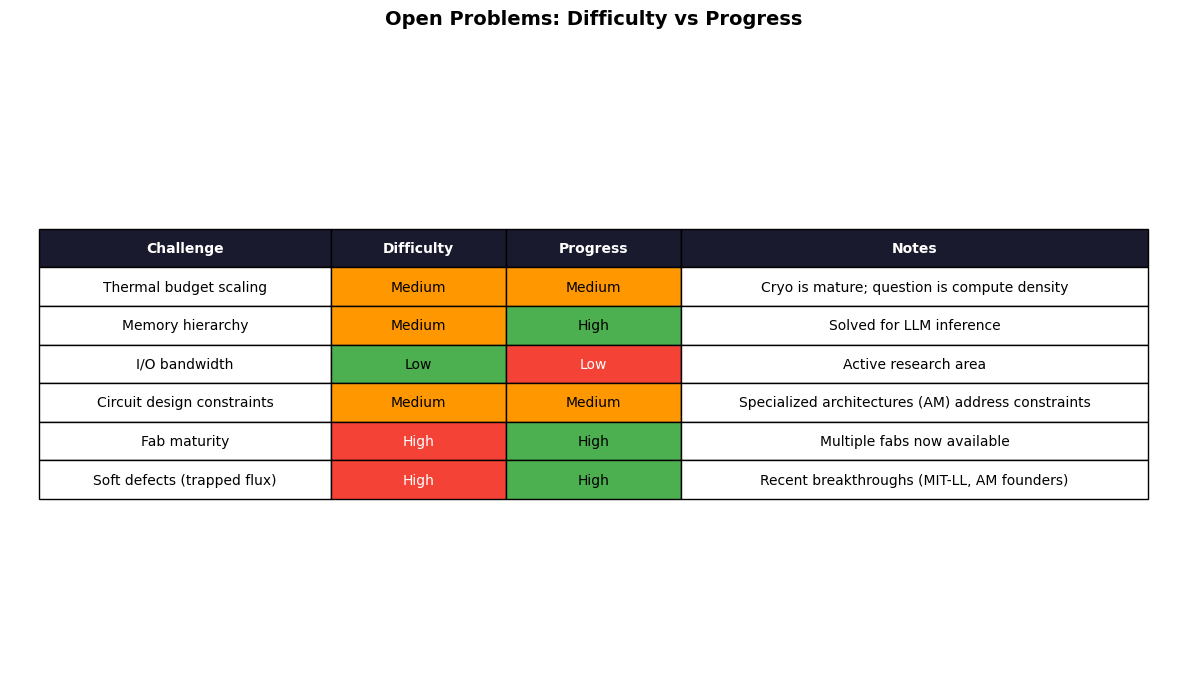


Key insight: Most challenges are engineering problems, not fundamental physics barriers.


In [7]:
# Visualize: Challenge/Opportunity matrix
fig, ax = plt.subplots(figsize=(12, 7))

challenges = [
    ('Thermal budget scaling', 'Medium', 'Medium', 'Cryo is mature; question is compute density'),
    ('Memory hierarchy', 'Medium', 'High', 'Solved for LLM inference'),
    ('I/O bandwidth', 'Low', 'Low', 'Active research area'),
    ('Circuit design constraints', 'Medium', 'Medium', 'Specialized architectures (AM) address constraints'),
    ('Fab maturity', 'High', 'High', 'Multiple fabs now available'),
    ('Soft defects (trapped flux)', 'High', 'High', 'Recent breakthroughs (MIT-LL, AM founders)'),
]

# Create table
ax.axis('off')
table_data = [['Challenge', 'Difficulty', 'Progress', 'Notes']] + \
             [[c[0], c[1], c[2], c[3]] for c in challenges]

# Separate color maps for Difficulty (high=bad) and Progress (high=good)
difficulty_colors = {
    'High': COLORS['danger'],      # Red = hard
    'Medium': COLORS['secondary'], # Orange = medium
    'Low': COLORS['success'],      # Green = easy
}
progress_colors = {
    'High': COLORS['success'],     # Green = good progress
    'Medium': COLORS['secondary'], # Orange = medium
    'Low': COLORS['danger'],       # Red = little progress
}

table = ax.table(cellText=table_data, loc='center', cellLoc='center',
                 colWidths=[0.25, 0.15, 0.15, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for j in range(4):
    table[(0, j)].set_facecolor(COLORS['dark'])
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Style cells with appropriate color semantics
for i in range(1, len(table_data)):
    diff = table_data[i][1]
    prog = table_data[i][2]
    # Difficulty column
    table[(i, 1)].set_facecolor(difficulty_colors.get(diff, 'white'))
    table[(i, 1)].set_text_props(color='white' if diff == 'High' else 'black')
    # Progress column (inverted semantics)
    table[(i, 2)].set_facecolor(progress_colors.get(prog, 'white'))
    table[(i, 2)].set_text_props(color='white' if prog == 'Low' else 'black')

ax.set_title('Open Problems: Difficulty vs Progress', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nKey insight: Most challenges are engineering problems, not fundamental physics barriers.")

---
<a id="7-path-forward"></a>
# 7. The Path Forward
---

## Why Now?

Several factors are converging to make this an exciting time for SCE:

1. **AI demand explosion**: Power limits are now the #1 constraint for hyperscalers
2. **CMOS hitting walls**: No clear path to 10× efficiency gains in CMOS
3. **Cryogenic maturity**: Quantum computing has driven cryo infrastructure investment
4. **Workload alignment**: LLMs have the predictable access patterns SCE needs

## The SCE Landscape

Superconducting electronics is an active field with multiple companies and research groups pursuing different applications:

| Organization | Focus | Approach |
|--------------|-------|----------|
| **Google Quantum AI** | Qubit control | AQFP for low-power control electronics |
| **SeeQC** | Quantum co-processing | SFQ-based digital control |
| **Hypres** (now SeeQC) | SFQ electronics | RSFQ pioneers, ADCs, digital RF |
| **MIT Lincoln Lab** | Fabrication & research | Advanced SCE processes, SFQ |
| **NIST** | Metrology & standards | Josephson voltage standards, quantum |
| **Yokohama National / AIST** | Ultra-low-power compute | AQFP research & MANA processor |
| **imec** | Research & development | SCE process development |
| **SkyWater** | Foundry services | Commercial SCE fabrication |

**Why the different approaches?**

- **Quantum control**: Both SFQ (fast pulses) and AQFP (low heat load at 4K) are viable
- **Classical compute** needs energy efficiency → AQFP excels (zeptojoule switching, adiabatic operation)

This course focuses on **AQFP for AI acceleration**—the ultra-low-power path to sustainable large-scale compute.

## Technology Roadmap

| Phase | Timeline | Milestone |
|-------|----------|----------|
| 1 | Now | Architecture validation, small prototypes |
| 2 | Near-term | Full-scale chip demonstration |
| 3 | Mid-term | System integration, pilot deployment |
| 4 | Longer-term | Production deployment, ecosystem growth |

## Why Study SCE?

- **Fundamental physics**: SCE operates near thermodynamic limits - a rare opportunity to work with technology that isn't fighting physics
- **Timing**: The field is early enough that individuals can make significant contributions
- **Interdisciplinary**: Combines quantum physics, materials science, circuit design, computer architecture, and systems engineering
- **Real applications**: Active development toward production deployments

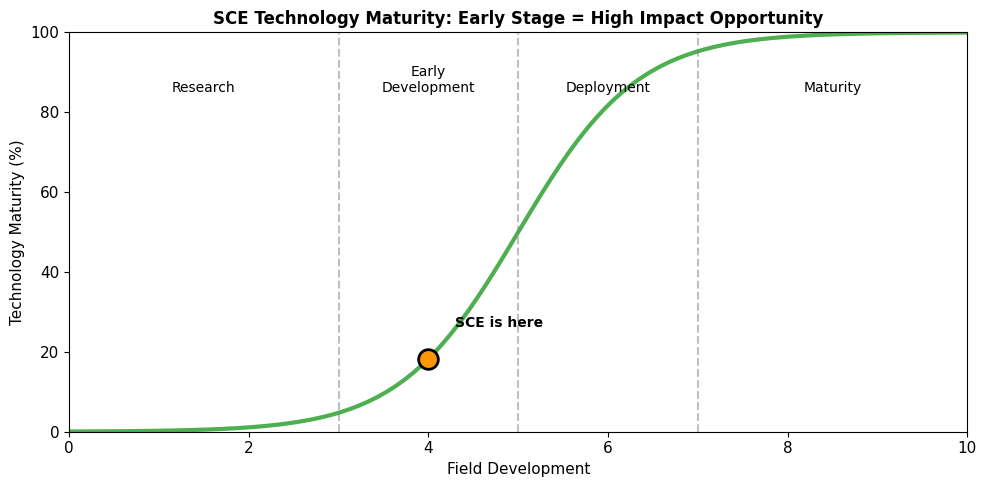

Early-stage fields offer the greatest opportunities for individual contribution.


In [8]:
# Visualize: Technology adoption and field maturity
fig, ax = plt.subplots(figsize=(10, 5))

# Technology maturity S-curve
x = np.linspace(0, 10, 100)
adoption = 100 / (1 + np.exp(-1.5*(x - 5)))  # S-curve

ax.plot(x, adoption, color=COLORS['sce'], linewidth=3)
ax.axvline(x=3, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=7, color='gray', linestyle='--', alpha=0.5)

ax.text(1.5, 85, 'Research', ha='center', fontsize=10)
ax.text(4, 85, 'Early\nDevelopment', ha='center', fontsize=10)
ax.text(6, 85, 'Deployment', ha='center', fontsize=10)
ax.text(8.5, 85, 'Maturity', ha='center', fontsize=10)

# SCE position - early development phase
sce_x = 4.0
sce_y = 100 / (1 + np.exp(-1.5*(sce_x - 5)))
ax.scatter([sce_x], [sce_y], s=200, color=COLORS['secondary'], zorder=5, edgecolors='black', linewidth=2)
ax.text(sce_x + 0.3, sce_y + 8, 'SCE is here', fontsize=10, fontweight='bold')

ax.set_xlabel('Field Development', fontsize=11)
ax.set_ylabel('Technology Maturity (%)', fontsize=11)
ax.set_title('SCE Technology Maturity: Early Stage = High Impact Opportunity', fontsize=12, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("Early-stage fields offer the greatest opportunities for individual contribution.")

---
<a id="8-takeaways"></a>
# 8. Key Takeaways
---

## The One-Slide Summary

| Question | Answer |
|----------|--------|
| **What is SCE?** | Computing with superconductors at ~4K, zero resistance |
| **Why now?** | AI power crisis + CMOS limits + cryo maturity |
| **How much better?** | **~100× (includes cooling)** |
| **For what workloads?** | AI inference, HPC - high arithmetic intensity, compute-dense |
| **Not for what?** | Mobile/edge, single-threaded, low-parallelism |
| **Key challenges?** | Thermal budget scaling, I/O bandwidth, fab density |
| **Status?** | Active development toward production |

## The Bottom Line

> **Superconducting electronics (AQFP) delivers ~100× system-level efficiency advantage over CMOS, including cooling overhead. The physics works. The engineering challenges are solvable. The market need is urgent.**

---

## Course Overview

This course will take you from fundamentals to system architecture:

**Part I: Foundations** - The physics of superconductivity

**Part II: Devices & Circuits** - From junctions to functional blocks

**Part III: Systems Integration** - Packaging, cooling, testing

**Part IV: Applications** - Classical uses and AI acceleration

Let's begin.